# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** [Co2 Emission per GDP and SDGs Achievement]
- **Student Name:** [Ai Nakayama]
- **Policy Relevance Statement:** [Finding out the best balance between economic development and a sustainable society]
- **Central Hypothesis:** [CO2 emissions are high in developing countries, but once they reach a certain point, I assume they will stabilize and start paying more attention to sustainability, as most developed countries do.]

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** Jorda-Schularick-Taylor (JST) Macrohistory Database (historical parquet format)
- **Secondary Data Source:** IMF World Economic Outlook (WEO) Countries Database (revenue series)
- **Variables Retrieved:** `date`, `country`, `country_name`, `rgdpmad` (real GDP), `debtgdp` (debt-to-GDP ratio), `gov_revenue_gdp` (revenue-to-GDP ratio)
- **Local Storage Path:** `data/final_project/first-last/macro_growth_debt.csv`



In [1]:
import os
import sys

sys.path.append(os.path.abspath("."))
print("位置情報の設定が完了しました。")

位置情報の設定が完了しました。


In [2]:
from data import load_and_clean_data

df_csv = load_and_clean_data("owid-co2-data.csv")
print(df_csv.head())

print("-" * 30)

【data.py】 owid-co2-data.csv からデータを読み込んでいます...
       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  0.0         0.0   
1  Afghanistan  1751      AFG         0.0  0.0         0.0   
2  Afghanistan  1752      AFG         0.0  0.0         0.0   
3  Afghanistan  1753      AFG         0.0  0.0         0.0   
4  Afghanistan  1754      AFG         0.0  0.0         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  0.0             0.0              0.0  ...   
1                    0.0  0.0             0.0              0.0  ...   
2                    0.0  0.0             0.0              0.0  ...   
3                    0.0  0.0             0.0              0.0  ...   
4                    0.0  0.0             0.0              0.0  ...   

   share_global_other_co2  share_of_temperature_change_from_ghg  \
0                     0.0                                   0.0   
1                   

In [3]:
import pandas as pd

df = pd.read_csv("owid-co2-data.csv")
print(df.columns.tolist())

['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita', 

In [4]:
from data import fetch_india_sdg13_data

# Fetch the data using the updated function
df_india = fetch_india_sdg13_data()

# Inspect the outputs safely
if df_india is not None and not df_india.empty:
    print("\n--- India SDG 13 Dataset Selected (2015-2025) ---")

    # Pick the most useful display columns from the API structure
    display_columns = [
        c
        for c in [
            "goal",
            "target",
            "indicator",
            "seriesCode",
            "seriesDescription",
            "timePeriodStart",
            "value",
        ]
        if c in df_india.columns
    ]

    # Display the first 10 rows
    display(df_india[display_columns].head(10))
else:
    print("DataFrame is empty. Please verify connectivity or params.")

【data.py】 国連SDG APIからインドのGoal 13データを取得中...
【data.py】 2015年〜2025年のデータを 76 件抽出しました！

--- India SDG 13 Dataset Selected (2015-2025) ---


,goal,target,indicator,seriesDescription,timePeriodStart,value
0,"[1, 11, 13]","[1.5, 11.5, 13.1]","[1.5.1, 11.5.1, 13.1.1]",Number of missing persons due to disaster (num...,2015,4
1,"[1, 11, 13]","[1.5, 11.5, 13.1]","[1.5.1, 11.5.1, 13.1.1]",Number of people affected by disaster (number),2015,187873332
2,"[1, 11, 13]","[1.5, 11.5, 13.1]","[1.5.1, 11.5.1, 13.1.1]",Number of deaths due to disaster (number),2015,7313
3,"[1, 11, 13]","[1.5, 11.5, 13.1]","[1.5.1, 11.5.1, 13.1.1]",Number of deaths and missing persons attribute...,2015,0.550968752
4,"[1, 11, 13]","[1.5, 11.5, 13.1]","[1.5.1, 11.5.1, 13.1.1]",Number of deaths and missing persons attribute...,2015,7317
5,"[1, 11, 13]","[1.5, 11.b, 13.1]","[1.5.3, 11.b.1, 13.1.2]",Score of adoption and implementation of nation...,2015,0.25
6,"[1, 11, 13]","[1.5, 11.5, 13.1]","[1.5.1, 11.5.1, 13.1.1]",Number of people whose damaged dwellings were ...,2015,187873332
7,"[1, 11, 13]","[1.5, 11.5, 13.1]","[1.5.1, 11.5.1, 13.1.1]",Number of directly affected persons attributed...,2015,14146.82728
8,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Proportion of local governments that adopt and...,2015,90.05848
9,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Number of local governments that adopt and imp...,2015,616


In [5]:
display(df_india[display_columns].tail(10))

,goal,target,indicator,seriesDescription,timePeriodStart,value
66,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Proportion of local governments that adopt and...,2021,91.632928
67,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Number of local governments that adopt and imp...,2021,679
68,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Number of local governments (number),2021,741
69,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Proportion of local governments that adopt and...,2022,93.126685
70,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Number of local governments that adopt and imp...,2022,691
71,"[1, 13, 11]","[1.5, 13.1, 11.b]","[1.5.4, 13.1.3, 11.b.2]",Number of local governments (number),2022,742
72,"[4, 12, 13]","[4.7, 12.8, 13.3]","[4.7.1, 12.8.1, 13.3.1]",Score on greening education in biodiversity (%),2023,29.62617683
73,"[4, 12, 13]","[4.7, 12.8, 13.3]","[4.7.1, 12.8.1, 13.3.1]",Score on greening education in climate change (%),2023,11.8156271
74,"[4, 12, 13]","[4.7, 12.8, 13.3]","[4.7.1, 12.8.1, 13.3.1]",Score on greening education in environment and...,2023,64.71540833
75,"[4, 12, 13]","[4.7, 12.8, 13.3]","[4.7.1, 12.8.1, 13.3.1]",Score on greening education in environment and...,2023,42.71815491


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Merging Strategy:** Country-year outer or left merge to pair JST macro history series with IMF government revenue data
- **Pre-cleaned Observations:** 427 matched rows (from 1960 onwards)
- **Final Dataset Observations:** 247 clean rows and 11 columns (post-1980, after dropping missing government revenue records)
- **Clean Data Path:** `data/final_project/first-last/processed_macro_data.csv`



In [6]:
from manipulate import preprocess_and_merge
df_final = preprocess_and_merge()

if df_final is not None:
    display(df_final.head())

【manipulate.py】 前処理とデータの結合を開始します...
【data.py】 owid-co2-data.csv からデータを読み込んでいます...
【data.py】 国連SDG APIからインドのGoal 13データを取得中...
【data.py】 2015年〜2025年のデータを 76 件抽出しました！

【国連データに存在する指標一覧】
  0: Number of missing persons due to disaster (number)
  1: Number of people affected by disaster (number)
  2: Number of deaths due to disaster (number)
  3: Number of deaths and missing persons attributed to disasters per 100,000 population (number)
  4: Number of deaths and missing persons attributed to disasters (number)
  5: Score of adoption and implementation of national DRR strategies in line with the Sendai Framework
  6: Number of people whose damaged dwellings were attributed to disasters (number)
  7: Number of directly affected persons attributed to disasters per 100,000 population (number)
  8: Proportion of local governments that adopt and implement local disaster risk reduction strategies in line with national disaster risk reduction strategies (%)
  9: Number of local governments that adop

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,time_detail,timeCoverage,upperBound,lowerBound,basePeriod,source,geoInfoUrl,footnotes,attributes.Nature,dimensions.Reporting Type
0,India,2015,IND,1.328024e+09,7.391522e+12,117.507912,0.088483,2231.817383,83.765503,3.899598,...,None,None,None,None,None,United Nations Office for Disaster Risk Reduct...,None,[Disclaimer: The data being submitted by UNDRR...,C,G
1,India,2016,IND,1.343944e+09,8.057466e+12,123.281311,0.091731,2352.540039,120.722687,5.409169,...,None,None,None,None,None,United Nations Office for Disaster Risk Reduct...,None,[Disclaimer: The data being submitted by UNDRR...,C,G
2,India,2017,IND,1.359657e+09,8.550030e+12,121.047241,0.089028,2425.721924,73.181694,3.110754,...,None,None,None,None,None,United Nations Office for Disaster Risk Reduct...,None,[Disclaimer: The data being submitted by UNDRR...,C,G
3,India,2018,IND,1.374659e+09,9.173202e+12,138.964890,0.101090,2595.227051,169.505280,6.987834,...,None,None,None,None,None,United Nations Office for Disaster Risk Reduct...,None,[Disclaimer: The data being submitted by UNDRR...,C,G
4,India,2019,IND,1.389030e+09,9.595463e+12,143.664139,0.103428,2611.174561,15.947520,0.614500,...,None,None,None,None,None,United Nations Office for Disaster Risk Reduct...,None,[Disclaimer: The data being submitted by UNDRR...,C,G


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure Key Takeaway:** [There is no direct correlation between SDG 13 Indicator Value and O2 emissions per GDP. Still, in the years 2016-17, when the Indicator Value increased, CO2 emissions decreased, so it may be assumed that there is an externality influencing each indicator independently. As a result, the two looked like having a correlation with each other.]




【graph.py】 グラフを作成しています...
【graph.py】 青い点を 7 件プロットしました。


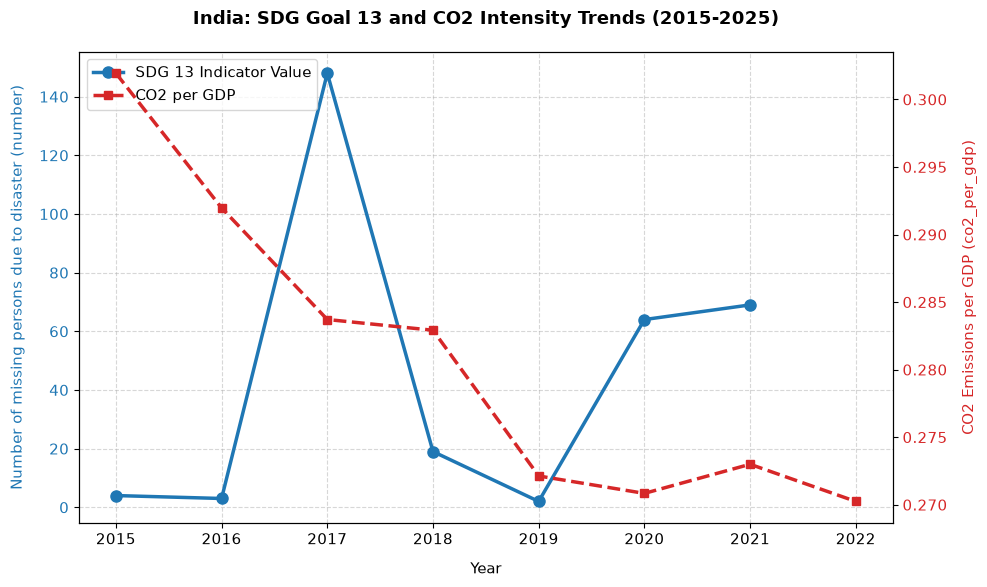

In [7]:
from graph import plot_india_sdg_trends
plot_india_sdg_trends()

## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** Panel Ordinary Least Squares (PanelOLS) with Entity Fixed Effects
- **Model Fit Metrics:** R-squared = 0.1191, Number of Observations = 247
- **Coefficient of Primary Variable (debt_change_lag1):** Coefficient: 9.4777, Std. Err: 4.4320, T-stat: 2.1385 (p-value: 0.0335)
- **Statistical Significance:** Both lagged debt changes (p < 0.05) and government revenue percentage (p < 0.05) are statistically significant.
- **Key Conclusion:** Including government revenue to GDP control variable restricts our panel to the post-1980 period. In this era, increases in government revenue-to-GDP are associated with lower subsequent economic growth, while short-run lagged debt ratio changes show a positive correlation with current growth in the presence of control variables.



In [5]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.7 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 3.6 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.5 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.5 MB 3.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 3.6 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 3.6 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.5 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 3.6 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 3.6 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 3.6 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 3.6 MB/s eta 0:00:01
   ----------------

In [8]:
from model import run_india_ols_regression

analysis_results = run_india_ols_regression()

【model.py】 インドの実データを用いたOLS回帰分析を開始します...
---------------------------------------------------------------------------
◎ 従属変数 (Dependent Variable): SDG Goal 13 Indicator Value ('value')
◎ 独立変数 (Independent Variable): CO2 Emissions per GDP ('co2_per_gdp')
◎ 分析対象期間: 2015年 〜 2021年
◎ サンプルサイズ (Observations): 7 件
---------------------------------------------------------------------------
【1】 Full OLS Regression Summary
                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                 -0.099
Method:                 Least Squares   F-statistic:                    0.4573
Date:                Sun, 12 Jul 2026   Prob (F-statistic):              0.529
Time:                        18:10:36   Log-Likelihood:                -37.013
No. Observations:                   7   AIC:                             78.03
Df Residuals:                    

c:\Users\eye24\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
